<a href="https://colab.research.google.com/github/epythonlab2/fintech-ml-labs/blob/main/anomaly_detection_using_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **Advanced Machine Leaning Fraud Detection: Anomaly Detection using IsolationForest**

## Introduction

Hey, welcome. Today, I’m going to show you how to build a production-ready anomaly detection pipeline using Isolation Forests. You’ll learn the system design behind it and how to make the technical trade-offs that actually matter in the real world.

## Loading the data

Before I even think about modeling, I need to load and inspect the data with the right mindset.

I’ll walk you through how to construct and load a realistic dataset that reflects production challenges. This ensures you’re not just building a solution that works in a notebook, but one that actually survives in the real world.

So, I import pandas and use read_csv to load the data.

In [ ]:
import pandas as pd

df = pd.read_csv("anomaly.csv")

Now that I’ve loaded the data into a DataFrame, the next step is to understand what I’m actually working with.

This is where I need to slow down.
Before building any model, I should explore the variables — their distributions, ranges, and potential issues.

Because if I don’t understand the data, I’ll end up building on assumptions instead of reality.

So next, I’ll walk through how to properly explore and interpret these variables.

In [ ]:
# I use df.head() to inspect the first few rows.
df.head()

,transaction_amount,account_age_days,num_prev_transactions,location_distance_km,hour_of_day,is_weekend,device_type,is_fraud
0,46.926809,817,53,24.689230,8,1,mobile,0
1,NaN,567,46,19.486892,12,1,mobile,0
2,131.674569,1366,43,16.136038,17,1,tablet,0
3,91.294255,397,58,12.249393,14,1,tablet,0
4,16.962487,279,54,7.845625,16,0,mobile,0


Now that I've loaded the data, I need to define exactly what these variables represent. If I misunderstand even one feature, it can distort the entire model.

- `transaction_amount:` The monetary value. I expect a heavy skew—mostly small transactions with a few huge ones that could signal an anomaly.

- `account_age_days:` How long the account has existed. New accounts often behave differently than mature ones.

- `num_prev_transactions:` The user's activity history. This helps me capture their typical volume.

- `location_distance_km:` The distance from the user’s typical location. A sudden large distance is a classic red flag.

- `hour_of_day:` The hour (0–23). I’m looking for unusual temporal patterns, like activity in the middle of the night.

- `is_weekend:` A binary flag for weekends, where behavior often shifts from the weekday norm.

device_type: Mobile, desktop, or tablet. A sudden change in device can be a strong signal.

- `is_fraud:` The target (1 for anomaly, 0 for normal). I have to treat this with caution because real-world labels are usually noisy or incomplete.

With these defined, I can start analyzing how they interact to reveal those hidden anomalies.

Now I’ll move from intuition to actual inspection. I’m not guessing anymore — I’m validating what the data is really doing.

In [ ]:
# So, I use df.shape to check the dimensions of the data—understanding exactly
# how many rows and columns I'm working with.
print(df.shape)

(500000, 8)


In [ ]:
"""
Then, I run df.info() to get a high-level look at the data types and see
if there are any missing values. In a production pipeline,
ensuring your numeric features are actually stored as floats or integers is critical;
if they’re incorrectly loaded as objects, the model will fail before it even starts.
"""
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_amount     460041 non-null  float64
 1   account_age_days       500000 non-null  int64  
 2   num_prev_transactions  500000 non-null  int64  
 3   location_distance_km   459930 non-null  float64
 4   hour_of_day            500000 non-null  int64  
 5   is_weekend             500000 non-null  int64  
 6   device_type            500000 non-null  object 
 7   is_fraud               500000 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 30.5+ MB
None


Therefore, the dataset contains 500,000 rows and 8 columns, indexed from 0 to 499999.

I can see that `transaction_amoun`t and `location_distance_km` contain missing values, which I’ll need to handle carefully since they may carry useful signals.

The `device_type` variable is categorical, while the rest — including target variable — are numeric.

At this point, I have a clear structural understanding of the data, so next I’ll move on to checking the percentage of missing values.

In [ ]:
df.isnull().sum()

,0
transaction_amount,39959
account_age_days,0
num_prev_transactions,0
location_distance_km,40070
hour_of_day,0
is_weekend,0
device_type,0
is_fraud,0


In [ ]:
# Missing values check
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing>0] * 100)

location_distance_km    8.0140
transaction_amount      7.9918
dtype: float64


Therefore, I can see that the missing values are consistent across both features — about 8.01% for location_distance_km and 7.99% for transaction_amount.

This is not negligible, and it’s also not extreme.

So I shouldn’t treat this as a minor cleanup step. Instead, I need to consider that this missingness could be systematic, not random.

Before deciding how to handle it, I’ll first check how these variables are distributed — because that will influence whether I impute, flag, or treat missing values as a separate signal.

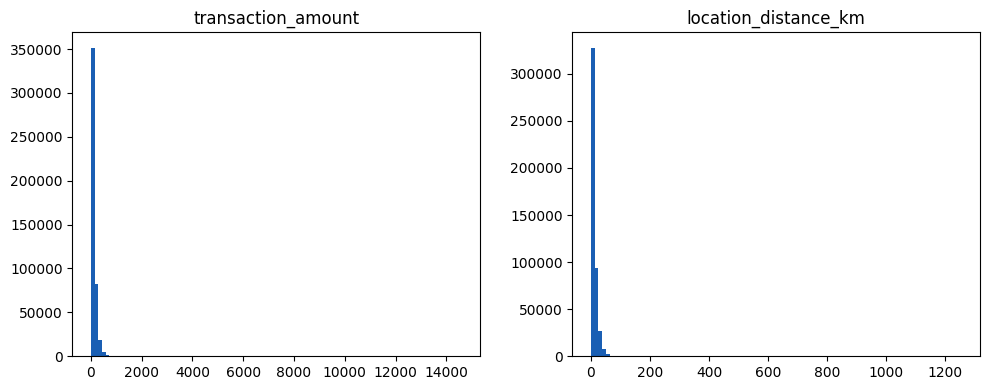

In [ ]:
import matplotlib.pyplot as plt

# Identifying the primary numerical features
cols = ["transaction_amount", "location_distance_km"]

# Plotting distributions to visualize the 'long tail'
# Using your preferred brand color #1a5fb4
df[cols].hist(bins=100, figsize=(10, 4), color='#1a5fb4', grid=False)


plt.tight_layout()
plt.show()

When I look at these distributions, I immediately see why a standard classification model would struggle.

Most of the data is tightly concentrated near the lower range, while a small number of points stretch far into long tails. That imbalance makes it hard for traditional models to learn a clear boundary.

For transaction_amount, most values sit below 500, but a few extend all the way to 14,000.
For location_distance_km, the pattern is similar — most activity happens within 50 km, with rare cases going beyond 1,000 km.

Those extreme values are not just outliers — they are exactly where anomalies tend to hide.

This is where Isolation Forest changes the approach.

Instead of modeling the dense region, I focus on how easily a point can be separated. Points in the main cluster require many splits to isolate, but these extreme tail values can be isolated in just a few splits.

That shorter path length becomes the signal — and that’s what I use to flag high-risk anomalies.

**Transition to Preprocessing**

Now that I understand the distributions, skewness, and missing values, the next step is to build a preprocessing pipeline.

I start by importing the core preprocessing components I’ll need to build a reliable pipeline.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Then I separate the features into numerical and categorical groups.



In [ ]:
# Separate features
numeric_cols = [
    "transaction_amount",
    "account_age_days",
    "num_prev_transactions",
    "location_distance_km",
    "hour_of_day"
]

categorical_cols = ["device_type", "is_weekend"]

Even though is_weekend is stored as an integer, I treat it as a categorical variable because it represents a binary state, not a continuous value.

Also, device_type contains categories like mobile, tablet, and laptop, so it clearly belongs in the categorical group.

Now I build the preprocessing pipeline — this is where I turn those decisions into something consistent and repeatable.

I first build numerical pipeline

In [ ]:
# Numerical pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # robust to outliers
    ("scaler", RobustScaler())
])

Here I use the Pipeline module to define a structured preprocessing flow.

I am applying SimpleImputer with a median strategy to handle missing values. I choose median specifically because the data is heavily skewed, and mean would be distorted by extreme values.

Then I apply RobustScaler to scale the numerical features. Unlike standard scaling, it uses the median and interquartile range, which makes it more stable in the presence of outliers — something I clearly observed in transaction_amount and location_distance_km.

This combination ensures that missing values are handled without biasing the data, and scaling does not get dominated by extreme values.

Then I apply a similar structured approach to the categorical features, but with a different goal.

In [ ]:
# Categorical pipeline
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [ ]:
categorical_pipeline

Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

Here, I use OneHotEncoder to properly encode variables like device_type. This converts each category into a separate binary column, so the model doesn’t assume any false ordering between categories.

I also set handle_unknown="ignore" to make the pipeline robust. This ensures that if a new category appears in production — something that wasn’t seen during training — the pipeline won’t break.

This step is critical because categorical data, if handled incorrectly, can introduce misleading patterns into the model.

And finally, I bring everything together into a single preprocessing step using ColumnTransformer.

In [ ]:
# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

This is where I connect the numerical and categorical pipelines so each feature is handled correctly and consistently.

At this point, I’ve defined a complete transformation layer.

This means any raw input data will now go through the same steps — imputation, scaling, and encoding — without me having to manually manage each part.

That consistency is what makes this pipeline reliable, especially when I move from experimentation to production.

Now that I have a complete preprocessing pipeline, the next step is to connect it to the model and train the system end-to-end.

This is where everything comes together — data preparation and anomaly detection in a single flow.

**Build the Full Pipeline with Isolation Forest**

I import IsolationForest.

Isolation Forest is an unsupervised anomaly detection algorithm that works by isolating data points rather than modeling normal behavior.

Instead of learning what is “normal,” it randomly splits the data using decision trees. Points that are very different from the majority get isolated much faster — meaning they require fewer splits.

This leads to a key idea:

- Normal points → require many splits to isolate
- Anomalies → isolated in very few splits

That difference is measured as path length, and shorter paths indicate higher likelihood of being an anomaly.

This makes Isolation Forest particularly effective in datasets like mine, where:

- Data is highly skewed
- Anomalies are rare
- Labels are unreliable or incomplete

So instead of forcing a definition of normal behavior, I let the model identify what stands out structurally.

In [ ]:
from sklearn.ensemble import IsolationForest

Then I build the full pipeline by combining the preprocessing step with the Isolation Forest model.

In [ ]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", IsolationForest(
        n_estimators=200,
        contamination=0.005,
        random_state=42
    ))
])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['transaction_amount', 'account_age_days',
                                  'num_prev_transactions',
                                  'location_distance_km', 'hour_of_day']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['device_type', 'is_weekend'])])

Here I specify the key parameters for the IsolationForest model: n_estimators, contamination, and random_state.

- n_estimators defines how many trees I use in the forest. More trees generally improve stability and reduce variance, but they also increase computation time. I’m balancing performance with efficiency here.

- contamination represents my assumption about the proportion of anomalies in the data. This is not something the model learns — I have to define it based on domain knowledge. In this case, I’m setting it to 0.5%, which aligns with the expected rarity of fraud.

- random_state ensures reproducibility. Since Isolation Forest relies on randomness to split data, fixing this value allows me to get consistent results across runs.

These are not arbitrary settings — they directly influence how sensitive the model is to anomalies and how stable the results will be.

Now that the pipeline is fully defined, the next step is to train the model and generate anomaly scores.

**Train the Pipeline**

Here I use the full dataset and simply drop the is_fraud column before training.

This is because Isolation Forest is an unsupervised model — it does not require a target variable.

Instead of learning from labeled examples, it learns the structure of the data and identifies points that deviate from that structure.

So by doing:

In [ ]:
pipeline.fit(df.drop(columns=["is_fraud"]))

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['transaction_amount',
                                                   'account_age_days',
                                                   'num_prev_transactions',
                                                   'location_distance_km',
                                                   'hour_of_day']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['device_type',
                                                   'is_weekend'])])),
                ('model',
                 IsolationForest(contamination=0.005, n_estimators=200,
                                 random_state=42))])

I’m allowing the model to discover anomalies based purely on patterns in the features — not on potentially incomplete or noisy labels.

This is important, because in real-world anomaly detection, relying too heavily on labels can actually limit what the model is able to detect.

At this point, everything is connected.

Raw data goes in → it gets cleaned, scaled, and encoded → then passed directly into the model.

This setup is critical because it guarantees consistency:

The same transformations are applied during training and inference

There’s no risk of mismatch between data preprocessing and model expectations


**Generate Anomaly Scores**

Once the model is trained, generate anomaly scores

In [ ]:
scores = pipeline.decision_function(df.drop(columns=["is_fraud"]))

These scores tell me how “normal” each point is:

- Higher score → more normal
- Lower score → more anomalous

**Convert to Predictions**
Then I convert the model output into usable predictions.

I use:

In [ ]:
preds = pipeline.predict(df.drop(columns=["is_fraud"]))

Isolation Forest returns:

- -1 → anomaly
- 1 → normal

So I convert this into a clearer binary format:

In [ ]:
preds = (preds == -1).astype(int)  # 1 = anomaly, 0 = normal

Then I generate a classification report against the target variable to understand how the model aligns with known labels.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df["is_fraud"], preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    497500
           1       0.66      0.66      0.66      2500

    accuracy                           1.00    500000
   macro avg       0.83      0.83      0.83    500000
weighted avg       1.00      1.00      1.00    500000



Therefore, the 1.00 accuracy is misleading due to extreme class imbalance (497,500 normal vs 2,500 anomalies). It does not reflect real model performance.

What actually matters is the anomaly class (1):

Precision = 0.66 → 66% of flagged anomalies are truly anomalous
Recall = 0.66 → the model detects 66% of all real anomalies
F1-score = 0.66 → balanced but moderate detection quality

For the normal class, performance is near perfect, but that is expected given its dominance in the dataset.

Conclusion:
The model is effectively learning meaningful anomaly structure, not random noise or class imbalance. However, it still misses ~34% of anomalies and produces some false positives, meaning there is clear room for improvement in feature engineering and threshold tuning.

**Error analysis and inspection of flagged anomalies**

Now I move into the most important phase:

👉 Error analysis and inspection of flagged anomalies

Now I extract the detected anomalies and attach their anomaly scores so I can analyze them more precisely.

In [ ]:
# Get anomaly predictions
df["pred"] = preds

# Filter anomalies
anomalies = df[df["pred"] == 1].copy()

# Attach anomaly scores
anomalies["anomaly_score"] = scores[df["pred"] == 1]

**Rank anomalies by severity**

At this point, I’m no longer just working with binary outputs.



Now I’m ready to rank, inspect, and analyze the highest-risk transactions in a more meaningful way.

In [ ]:
anomalies_sorted = anomalies.sort_values("anomaly_score")
anomalies_sorted.head(10)

,transaction_amount,account_age_days,num_prev_transactions,location_distance_km,hour_of_day,is_weekend,device_type,is_fraud,pred,anomaly_score
131991,2440.117243,87,36,108.330046,23,1,mobile,1,1,-0.106855
108778,4855.393475,1951,66,373.957415,18,1,tablet,1,1,-0.099786
56535,10873.383770,66,65,471.923704,23,1,tablet,1,1,-0.099445
313734,2808.925976,1787,66,371.653951,23,0,mobile,1,1,-0.097536
264195,8596.490199,27,44,643.176992,0,0,tablet,1,1,-0.096448
466475,1055.559052,86,33,91.652087,1,1,tablet,1,1,-0.093918
146408,3142.912611,355,68,163.301431,3,0,desktop,1,1,-0.093696
191833,2178.639831,1687,59,451.986792,23,0,desktop,1,1,-0.093059
307948,960.360902,119,62,118.689130,1,0,desktop,1,1,-0.092602
65127,1510.341232,1587,68,295.588535,23,1,desktop,1,1,-0.092540


I now have:

- Which transactions are anomalous
- How strongly anomalous each one is

This is important because in real systems, I don’t treat all anomalies equally. I prioritize them based on their score — focusing first on the most extreme cases, then gradually expanding to weaker signals.

**Validate signal quality**

What I’m validating here

I’m asking a simple but critical question:

Are these anomalies actually meaningful, or just mathematically extreme?

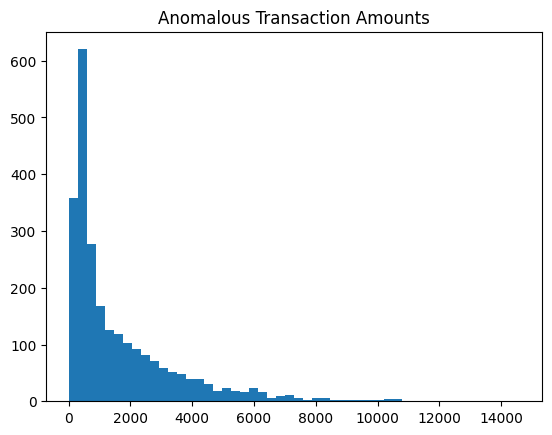

In [ ]:
import matplotlib.pyplot as plt

plt.hist(anomalies["transaction_amount"].dropna(), bins=50)
plt.title("Anomalous Transaction Amounts")
plt.show()

What I see:

Most anomalous transactions are still concentrated at lower values (0–2000)
But there is a long tail extending up to ~14,000
The density gradually decreases as the amount increases

The model is not only detecting extreme values.

If it were, you would only see spikes at very high amounts.
Instead, it’s also flagging subtle anomalies within lower ranges.

That’s a strong signal.

What This Means
>High-value transactions → obvious anomalies

>Low-to-mid range transactions → behavioral anomalies

This suggests your model is learning structure, not just magnitude.

What I’d Challenge

Now ask yourself:

>Are those low-value anomalies actually suspicious, or noise?

Because:

>If meaningful → your model is strong

>If random → you need better features